In [ ]:
from google.colab import files
uploaded = files.upload()

Saving agricultural_data.csv to agricultural_data.csv


In [ ]:
import pandas as pd

df = pd.read_csv("agricultural_data.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [ ]:
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
for i, col in enumerate(df.columns, start=1):
    print(i, ":", col)

1 : Farm_ID
2 : State
3 : District
4 : Crop
5 : Season
6 : Farm_Area_Hectares
7 : Rainfall_mm
8 : Avg_Temperature_C
9 : Humidity_pct
10 : Sunlight_Hours_Day
11 : Soil_pH
12 : Soil_Moisture_pct
13 : Nitrogen_kg_ha
14 : Phosphorus_kg_ha
15 : Potassium_kg_ha
16 : Irrigation_Method
17 : Fertilizer_kg_ha
18 : Pesticide_Litre_ha
19 : Seed_Quality_Score
20 : Yield_Tonnes_Ha
21 : Production_Tonnes
22 : Market_Price_INR_Tonne
23 : Total_Cost_INR
24 : Revenue_INR
25 : Profit_INR
26 : Water_Used_m3
27 : Water_Efficiency_t_per_1000m3
28 : Disease_Pest_Risk_pct


In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
missing_rows = df[df.isnull().any(axis=1)]

print("Rows containing missing values:", len(missing_rows))


Rows containing missing values: 120


In [ ]:
# Create a copy of the original dataset
df_clean = df.copy()

# Fill missing values with the median of each column
df_clean["Rainfall_mm"] = df_clean["Rainfall_mm"].fillna(
    df_clean["Rainfall_mm"].median()
)

df_clean["Soil_Moisture_pct"] = df_clean["Soil_Moisture_pct"].fillna(
    df_clean["Soil_Moisture_pct"].median()
)

df_clean["Yield_Tonnes_Ha"] = df_clean["Yield_Tonnes_Ha"].fillna(
    df_clean["Yield_Tonnes_Ha"].median()
)

# Check missing values after cleaning
print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

Missing values after cleaning:
0


In [ ]:
# Check for duplicate rows
duplicates = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Final dataset verification

print("Dataset shape:", df_clean.shape)
print("\nMissing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("\nData types:")
print(df_clean.dtypes)

Dataset shape: (4000, 28)

Missing values: 0
Duplicate rows: 0

Data types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR        

In [ ]:
df_clean.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [ ]:
crop_counts = df_clean["Crop"].value_counts()

print("Number of farms for each crop:")
print(crop_counts)

Number of farms for each crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


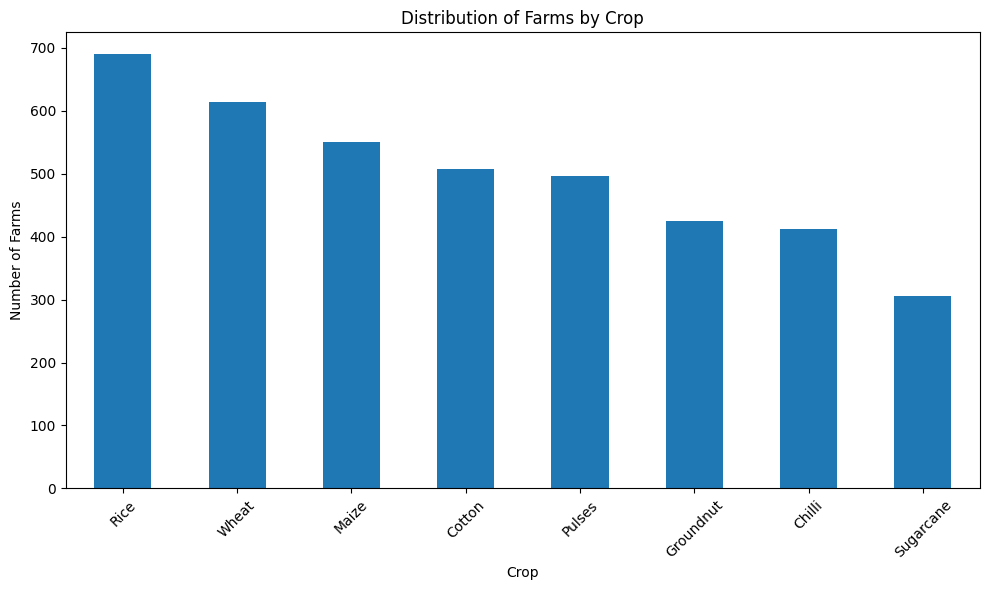

In [ ]:
import matplotlib.pyplot as plt

crop_counts = df_clean["Crop"].value_counts()

plt.figure(figsize=(10, 6))
crop_counts.plot(kind="bar")

plt.title("Distribution of Farms by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
season_counts = df_clean["Season"].value_counts()

print("Number of farms for each season:")
print(season_counts)

Number of farms for each season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


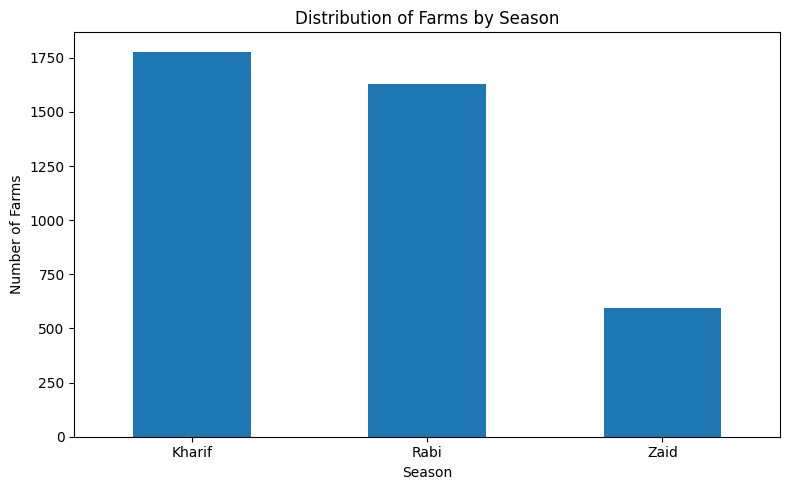

In [ ]:
import matplotlib.pyplot as plt

season_counts = df_clean["Season"].value_counts()

plt.figure(figsize=(8, 5))
season_counts.plot(kind="bar")

plt.title("Distribution of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
irrigation_counts = df_clean["Irrigation_Method"].value_counts()

print("Number of farms for each irrigation method:")
print(irrigation_counts)

Number of farms for each irrigation method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


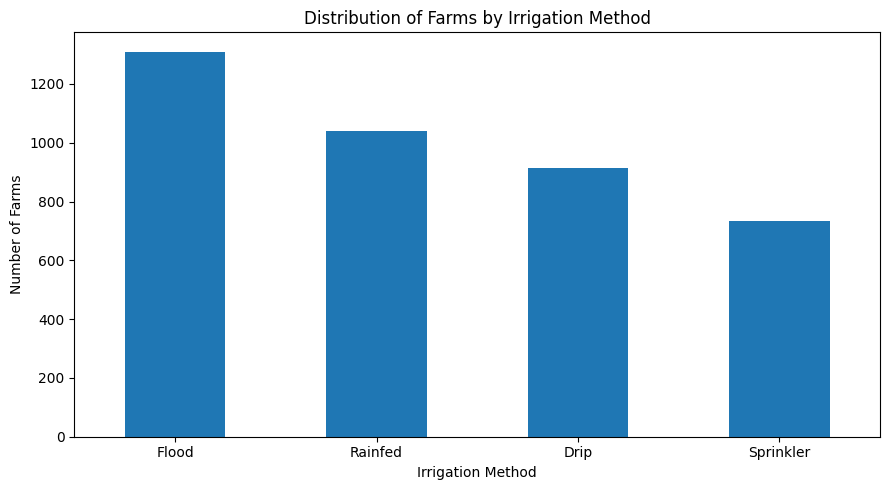

In [ ]:
import matplotlib.pyplot as plt

irrigation_counts = df_clean["Irrigation_Method"].value_counts()

plt.figure(figsize=(9, 5))
irrigation_counts.plot(kind="bar")

plt.title("Distribution of Farms by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

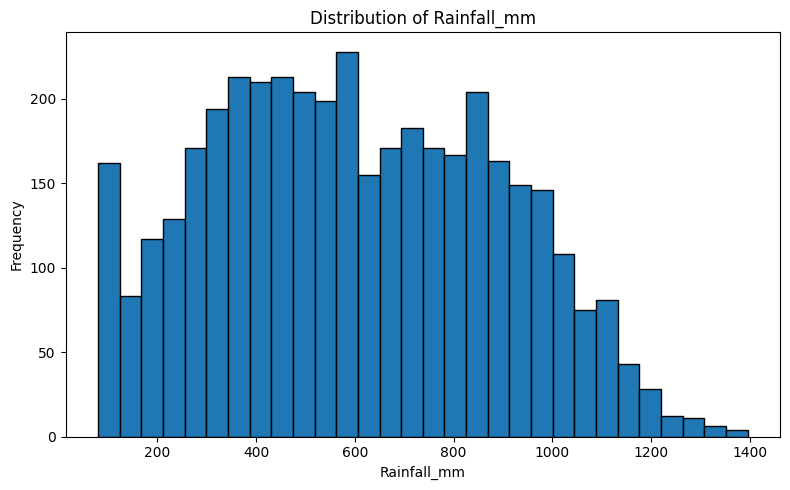

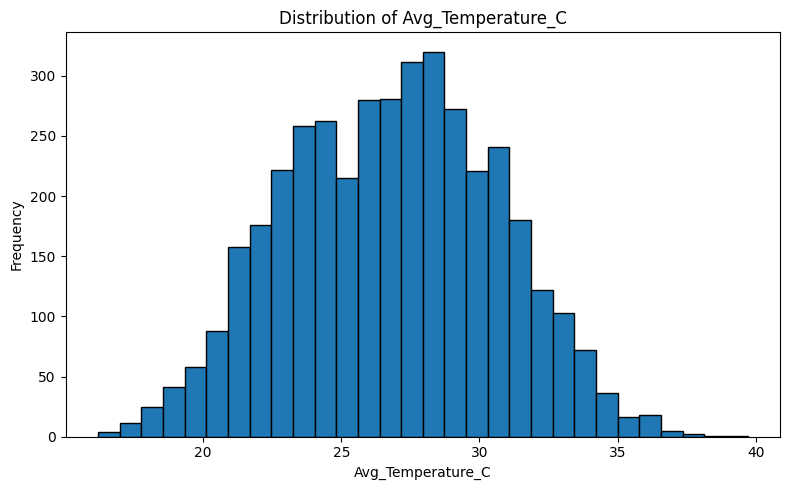

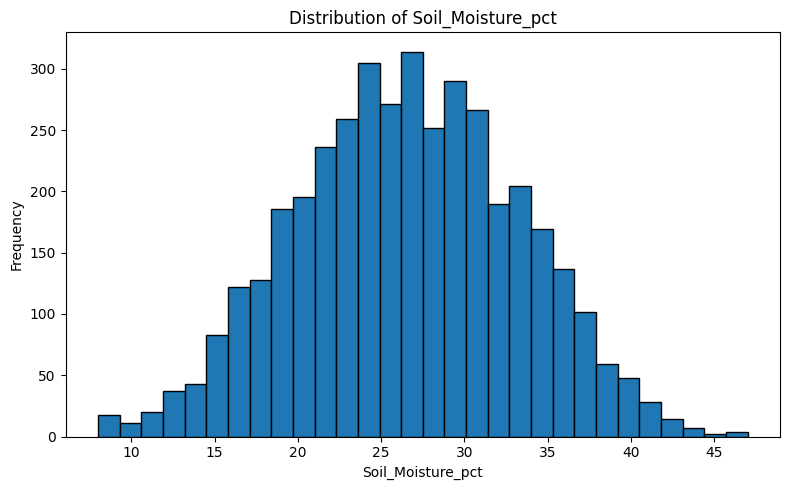

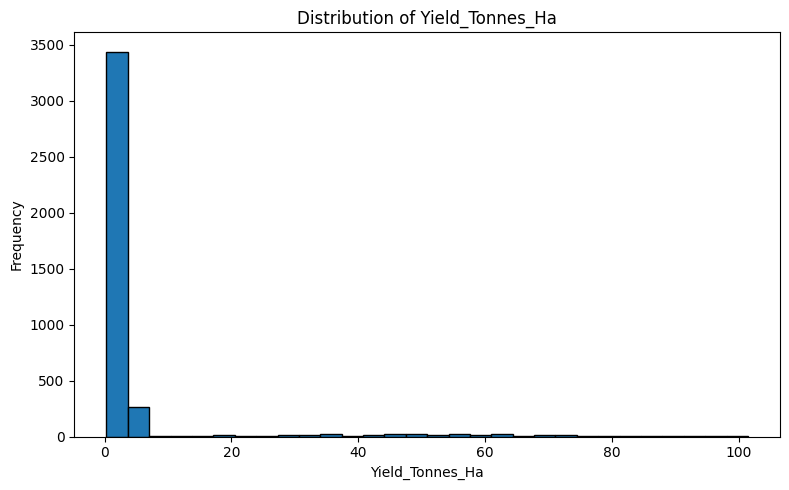

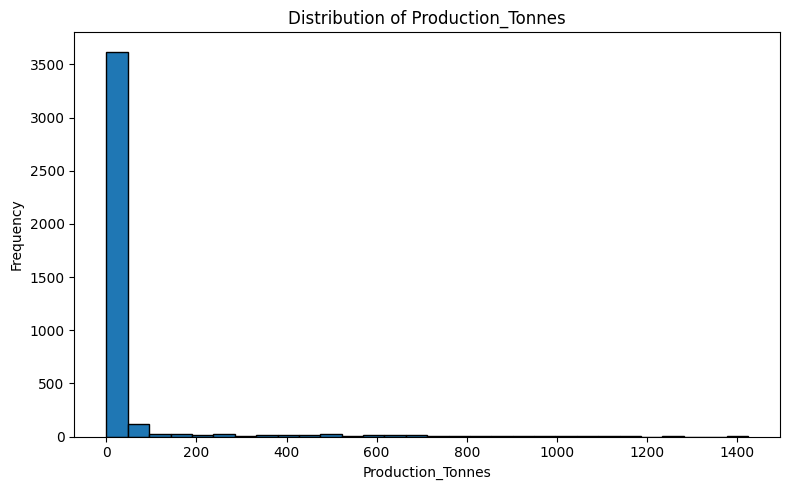

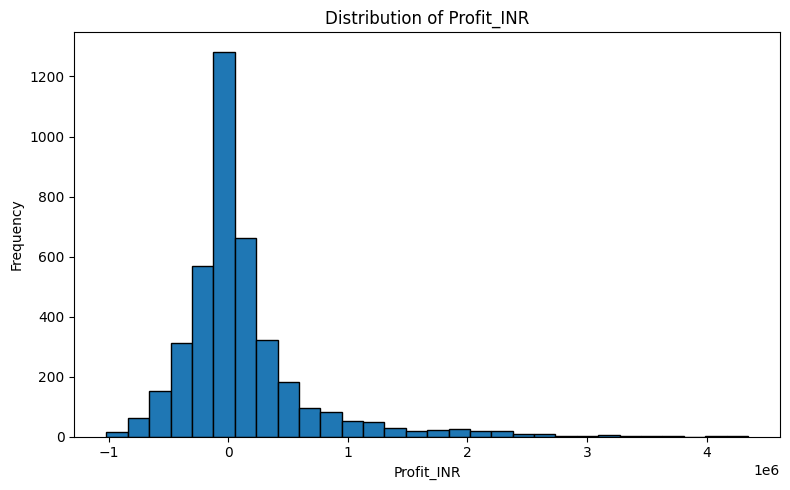

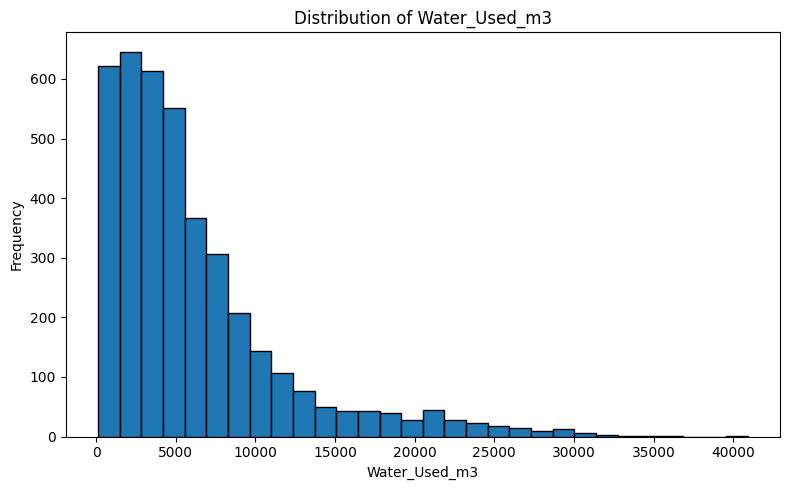

In [ ]:
import matplotlib.pyplot as plt

numerical_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3"
]

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df_clean[column], bins=30, edgecolor="black")

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

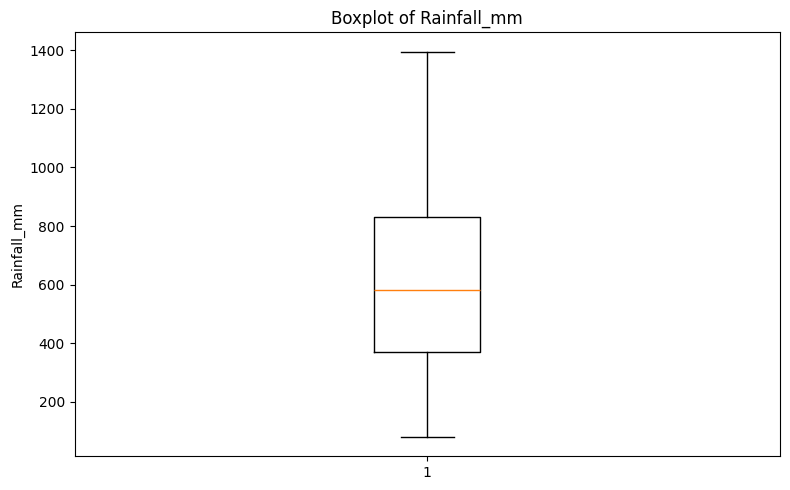

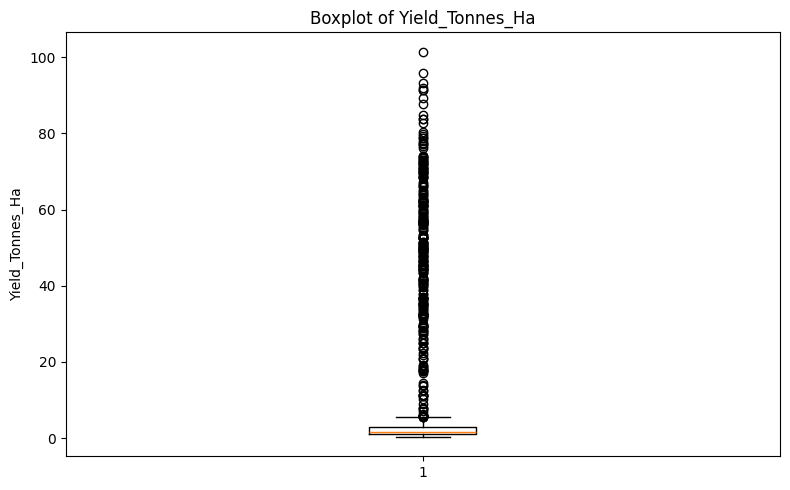

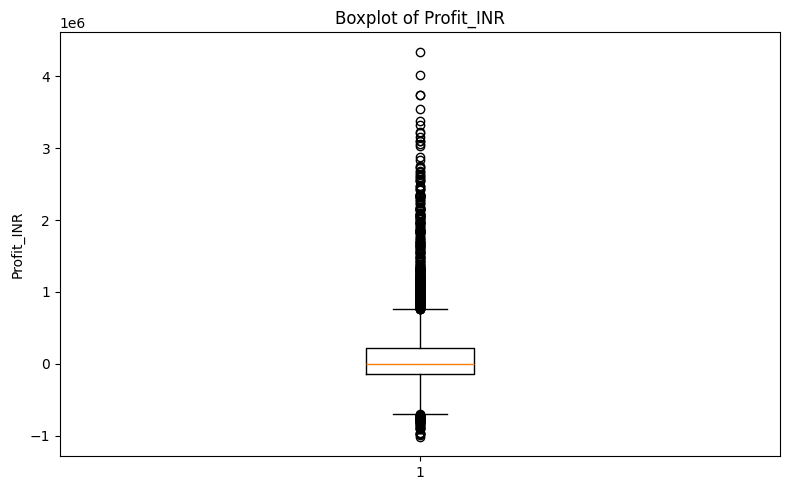

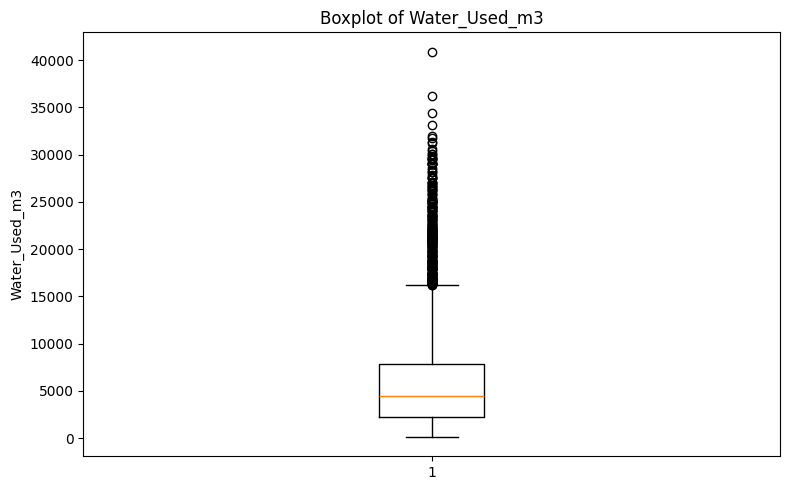

In [ ]:
import matplotlib.pyplot as plt

outlier_columns = [
    "Rainfall_mm",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3"
]

for column in outlier_columns:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_clean[column].dropna())

    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [ ]:
season_summary = df_clean.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_summary

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Rainfall,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,849.20,6102.20,5.89,54.47
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,437.62,5846.99,5.19,40.48
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,304.65,6419.89,4.41,38.22


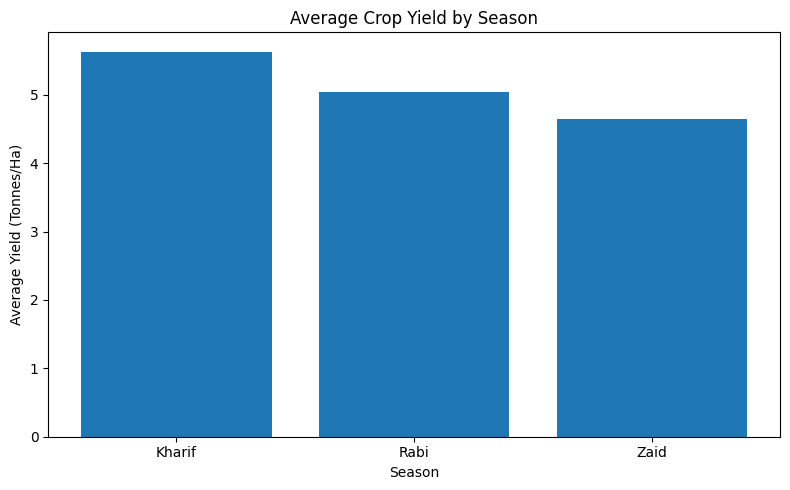

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["Avg_Yield"]
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

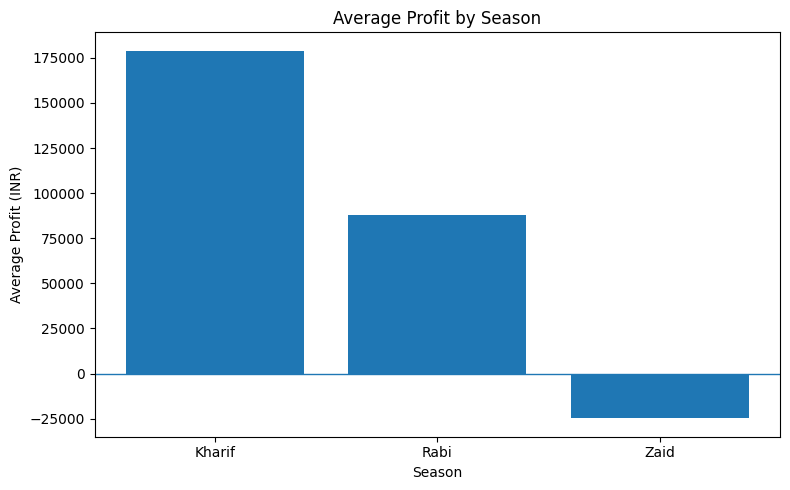

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["Avg_Profit"]
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

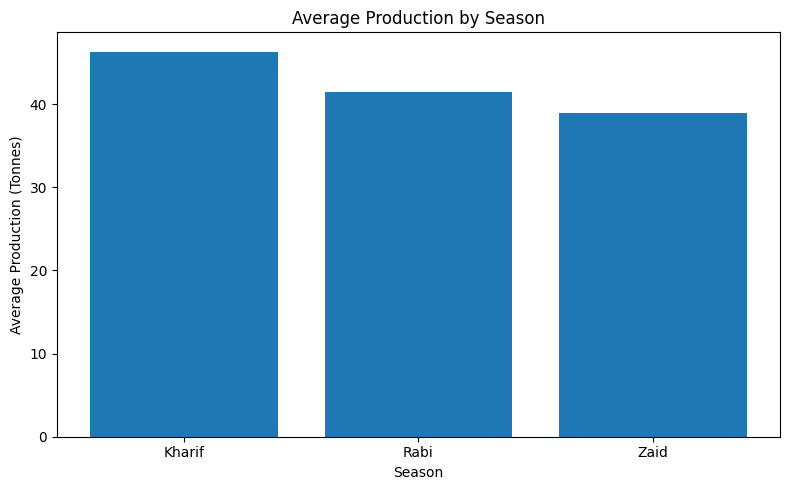

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["Avg_Production"]
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.tight_layout()
plt.show()

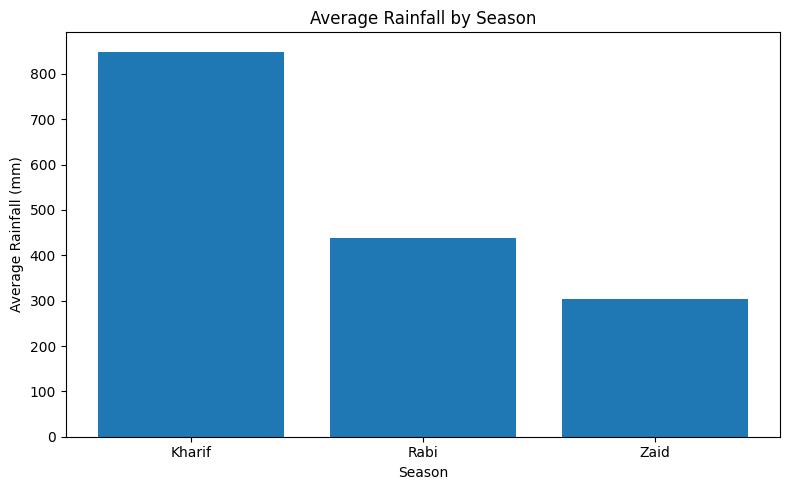

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["Avg_Rainfall"]
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.tight_layout()
plt.show()

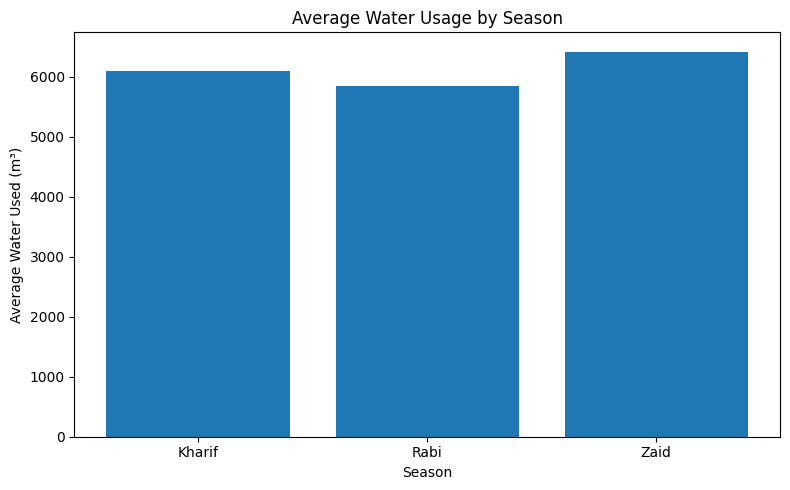

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["Avg_Water_Used"]
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

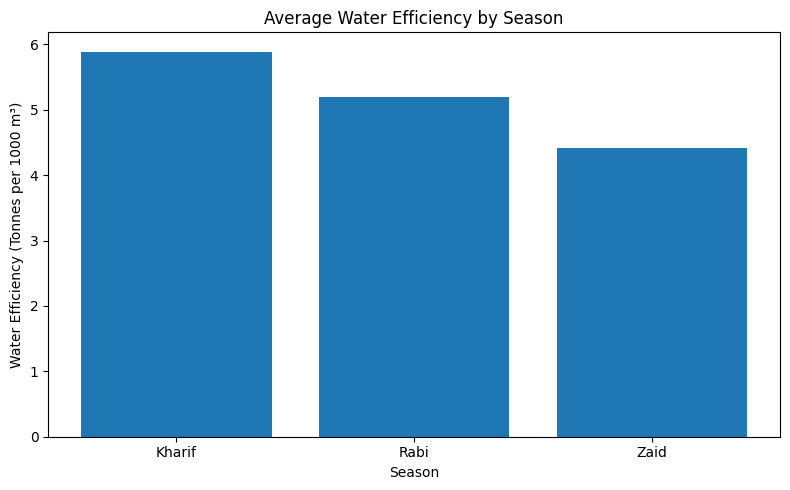

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["Avg_Water_Efficiency"]
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.tight_layout()
plt.show()

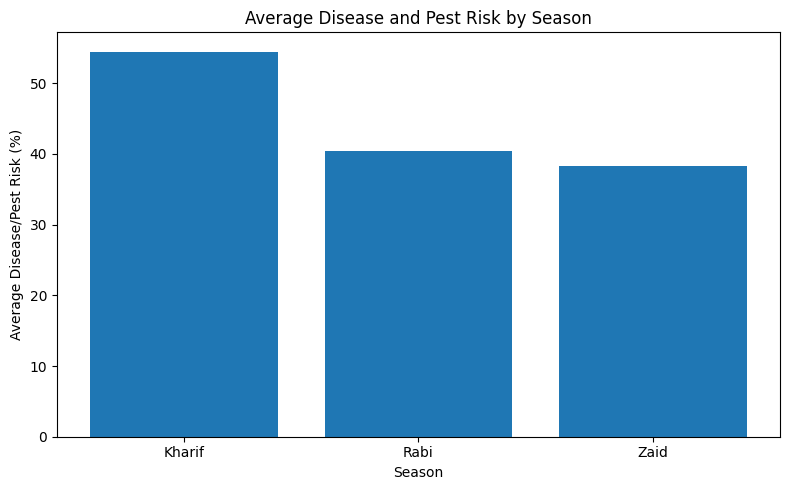

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["Avg_Disease_Risk"]
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Average Disease/Pest Risk (%)")
plt.tight_layout()
plt.show()

In [ ]:
crop_summary = df_clean.groupby("Crop").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Avg_Yield", ascending=False).round(2)

crop_summary

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Crop,,,,,,,,,
Sugarcane,305,46.64,392.41,1371980.11,554792.13,817187.99,13897.70,30.48,45.40
Maize,551,2.71,21.78,457067.99,541046.32,-83978.33,4377.78,5.60,45.54
Rice,690,2.43,19.29,423615.26,525828.76,-102213.50,10920.22,1.95,46.50
Wheat,614,2.11,16.85,400104.89,523503.22,-123398.34,4054.40,4.63,47.85
Chilli,412,1.54,12.38,1276777.23,525898.89,750878.34,4577.47,2.95,46.06
Groundnut,424,1.32,9.66,542935.50,498077.38,44858.12,3459.54,3.15,46.29
Cotton,508,1.23,9.40,639423.08,514876.17,124546.92,5410.86,1.94,45.97
Pulses,496,0.92,7.40,528465.87,532703.92,-4238.05,2833.67,2.90,46.57


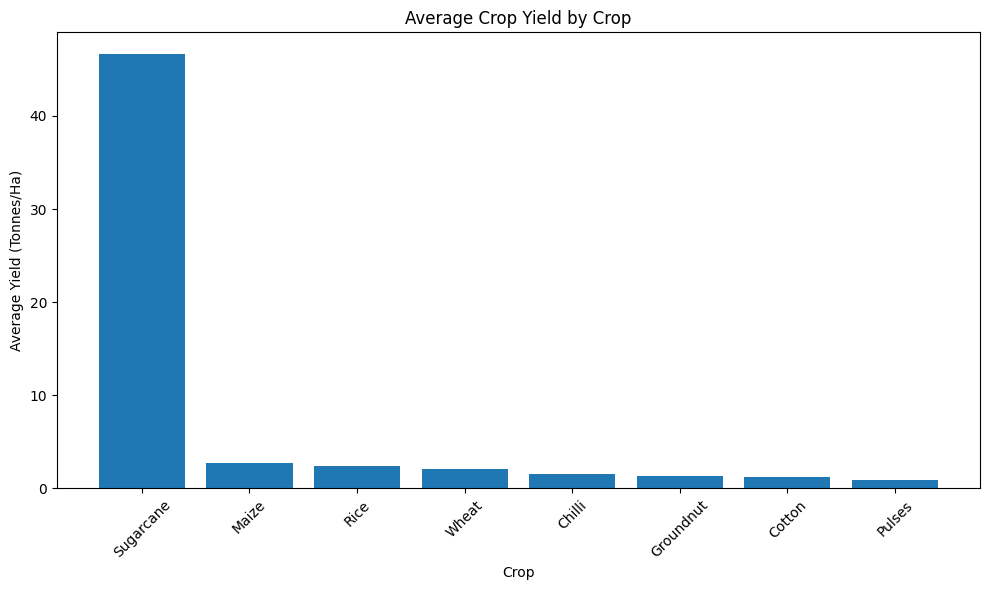

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    crop_summary.index,
    crop_summary["Avg_Yield"]
)

plt.title("Average Crop Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

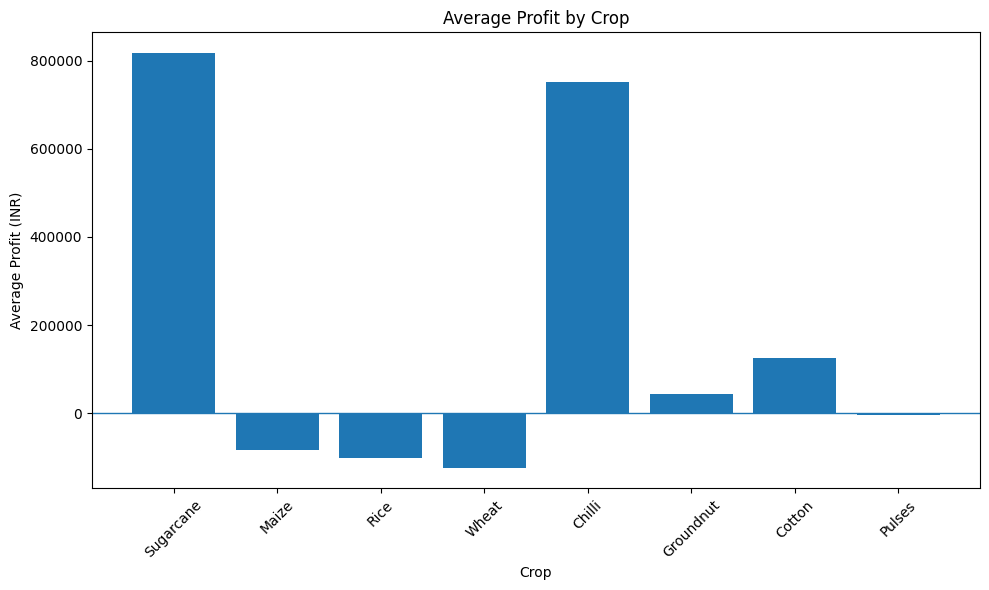

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    crop_summary.index,
    crop_summary["Avg_Profit"]
)

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

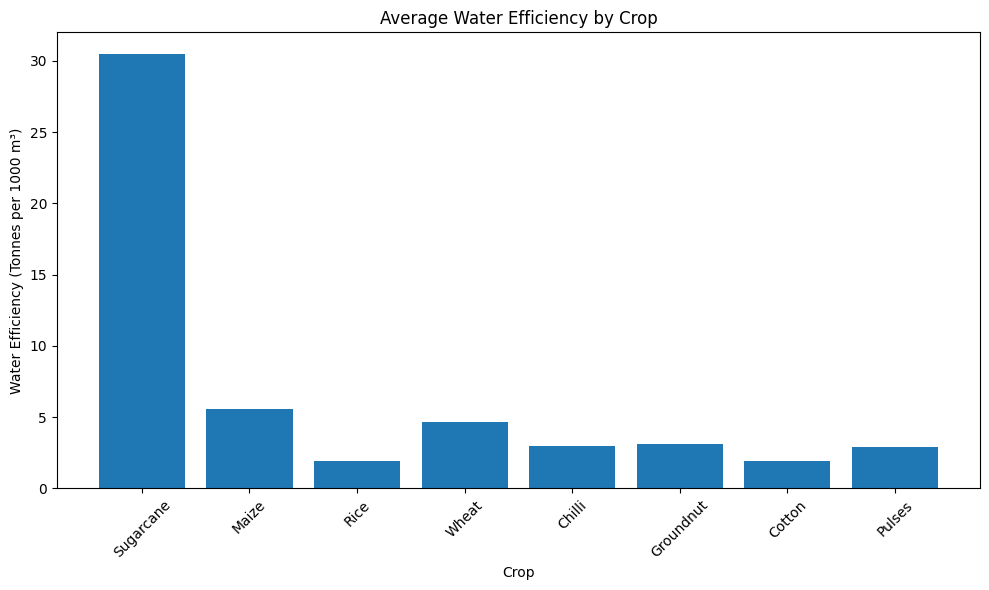

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    crop_summary.index,
    crop_summary["Avg_Water_Efficiency"]
)

plt.title("Average Water Efficiency by Crop")
plt.xlabel("Crop")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
crop_season_yield = df_clean.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


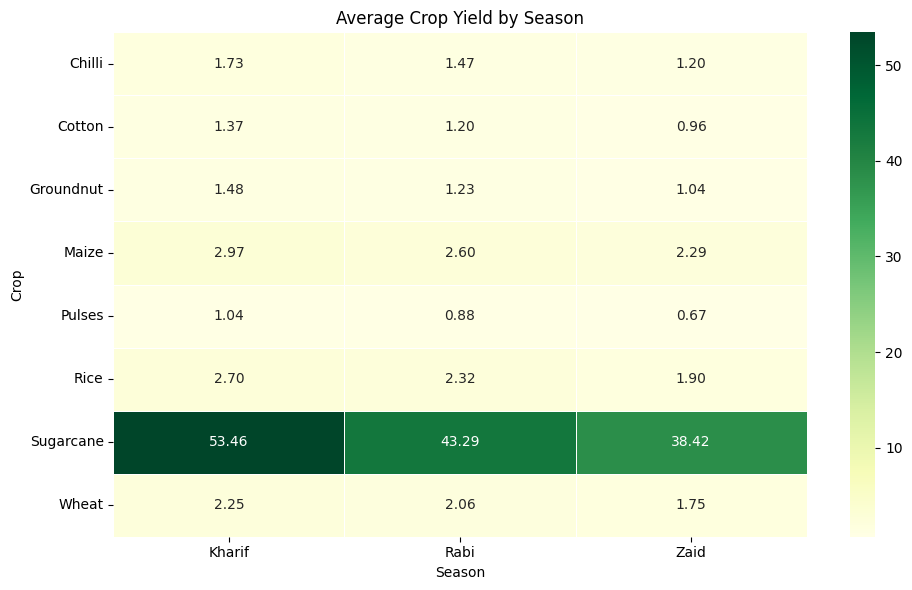

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

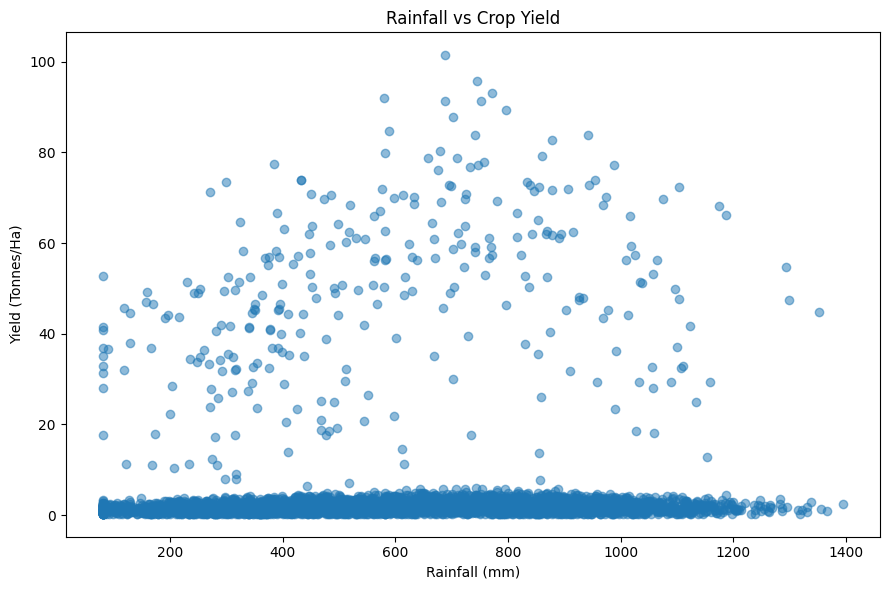

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Rainfall_mm"],
    df_clean["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

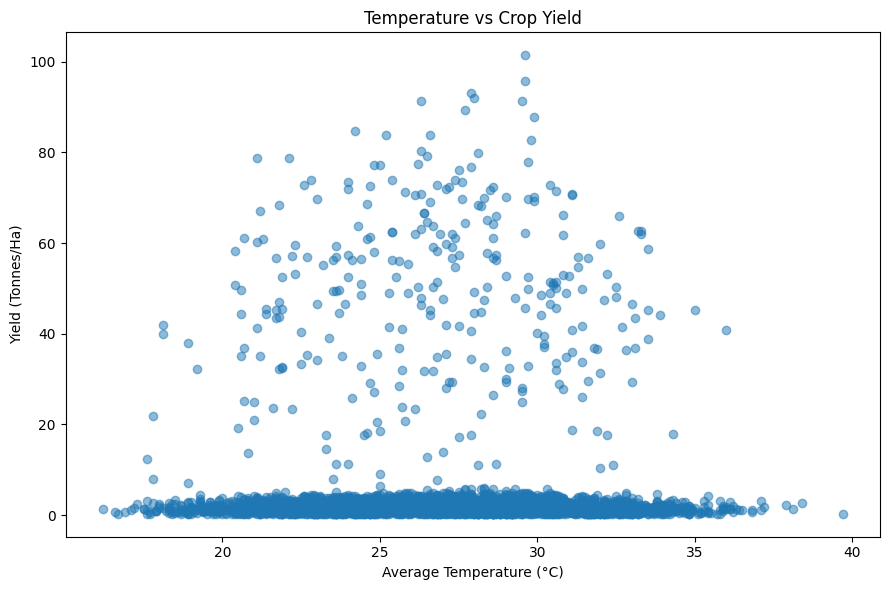

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Avg_Temperature_C"],
    df_clean["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

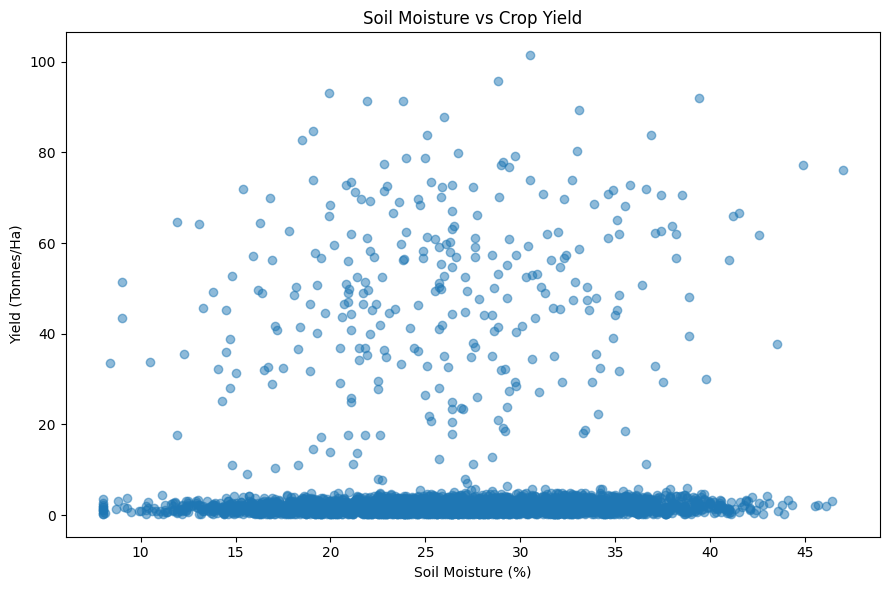

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Soil_Moisture_pct"],
    df_clean["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Soil Moisture vs Crop Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

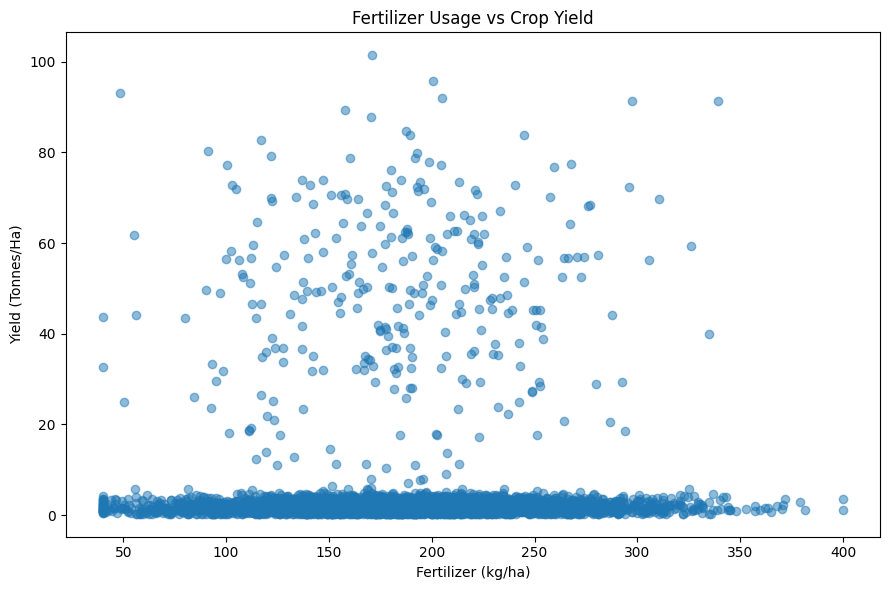

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Fertilizer_kg_ha"],
    df_clean["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

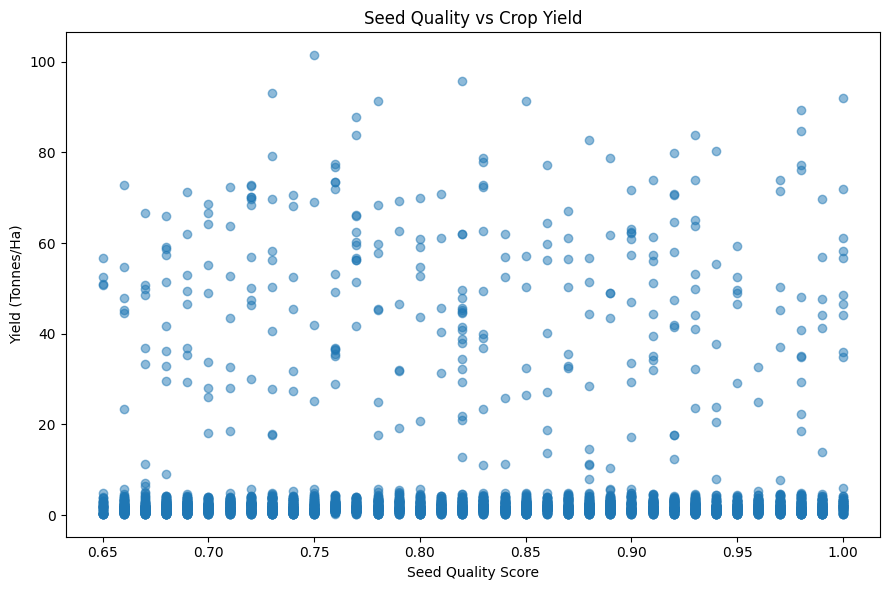

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Seed_Quality_Score"],
    df_clean["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Seed Quality vs Crop Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [ ]:
environmental_corr = df_clean[
    ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
     "Sunlight_Hours_Day", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
].corr()

print(environmental_corr["Yield_Tonnes_Ha"].sort_values(ascending=False))

Yield_Tonnes_Ha       1.000000
Rainfall_mm           0.030951
Humidity_pct          0.012297
Soil_Moisture_pct     0.010999
Avg_Temperature_C     0.009996
Sunlight_Hours_Day   -0.015341
Name: Yield_Tonnes_Ha, dtype: float64


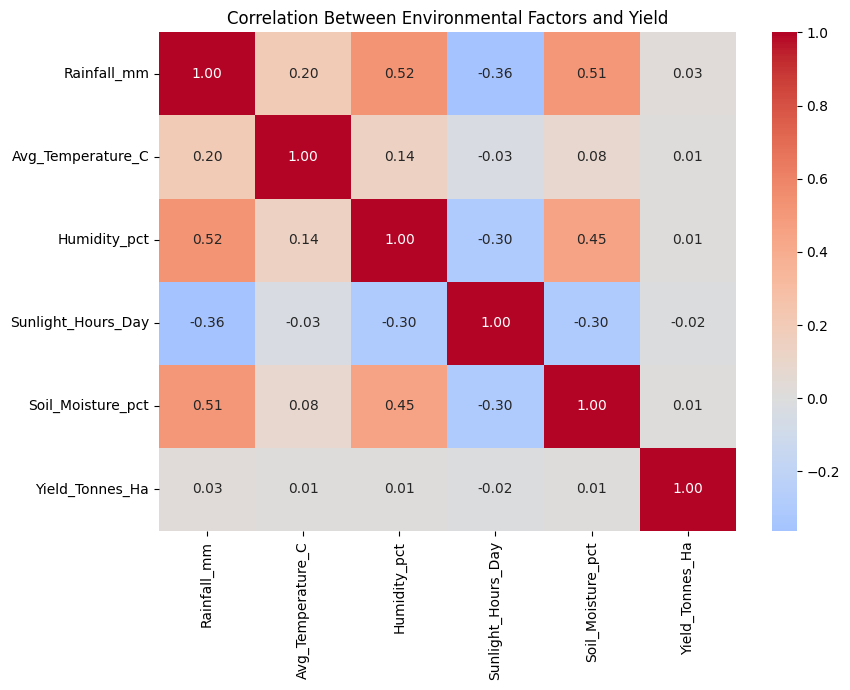

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    environmental_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Environmental Factors and Yield")
plt.tight_layout()
plt.show()

In [ ]:
environmental_season = df_clean.groupby("Season")[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]].mean().round(2)

print(environmental_season)

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                     
Kharif       849.20              28.45         71.81                6.79   
Rabi         437.62              23.49         57.89                7.59   
Zaid         304.65              31.04         52.01                8.18   

        Soil_Moisture_pct  Yield_Tonnes_Ha  
Season                                      
Kharif              31.15             5.63  
Rabi                24.07             5.04  
Zaid                19.28             4.64  


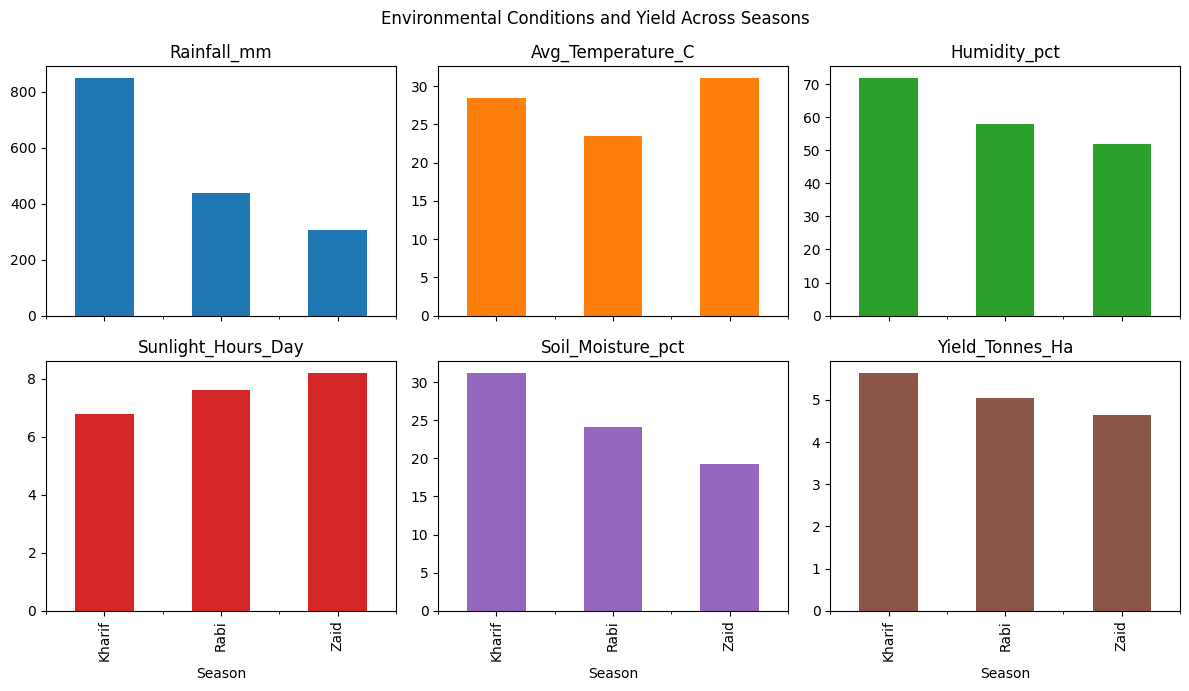

In [ ]:
environmental_season.plot(
    kind="bar",
    figsize=(12, 7),
    subplots=True,
    layout=(2, 3),
    legend=False
)

plt.suptitle("Environmental Conditions and Yield Across Seasons")
plt.tight_layout()
plt.show()

In [ ]:
irrigation_season = pd.crosstab(
    df_clean["Season"],
    df_clean["Irrigation_Method"]
)

print(irrigation_season)

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120


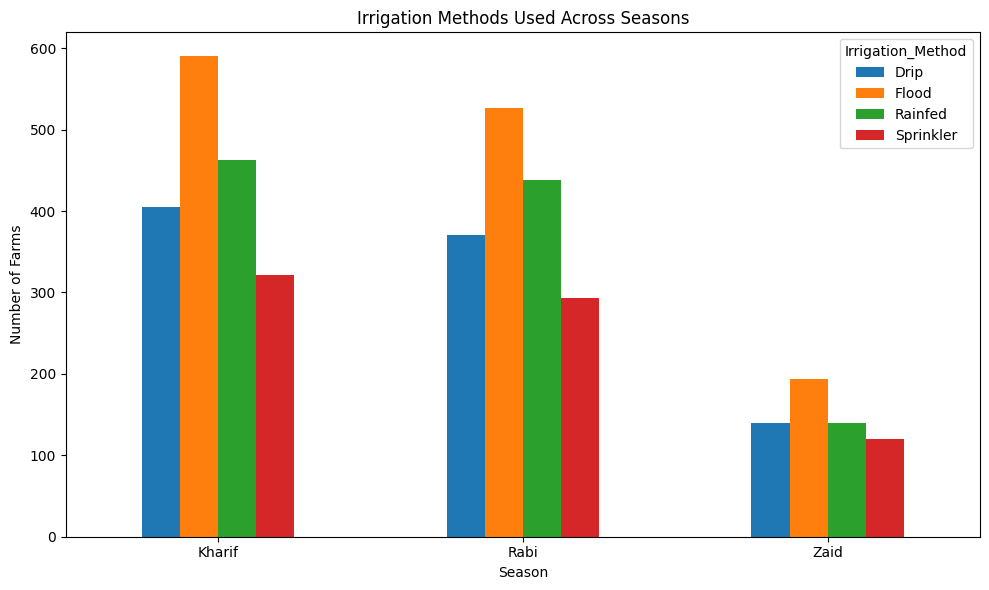

In [ ]:
irrigation_season.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Irrigation Methods Used Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
resource_season = df_clean.groupby("Season")[[
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha"
]].mean().round(2)

print(resource_season)

        Water_Used_m3  Water_Efficiency_t_per_1000m3  Fertilizer_kg_ha  \
Season                                                                   
Kharif        6102.20                           5.89            187.08   
Rabi          5846.99                           5.19            185.41   
Zaid          6419.89                           4.41            184.64   

        Pesticide_Litre_ha  
Season                      
Kharif                5.08  
Rabi                  5.02  
Zaid                  5.17  


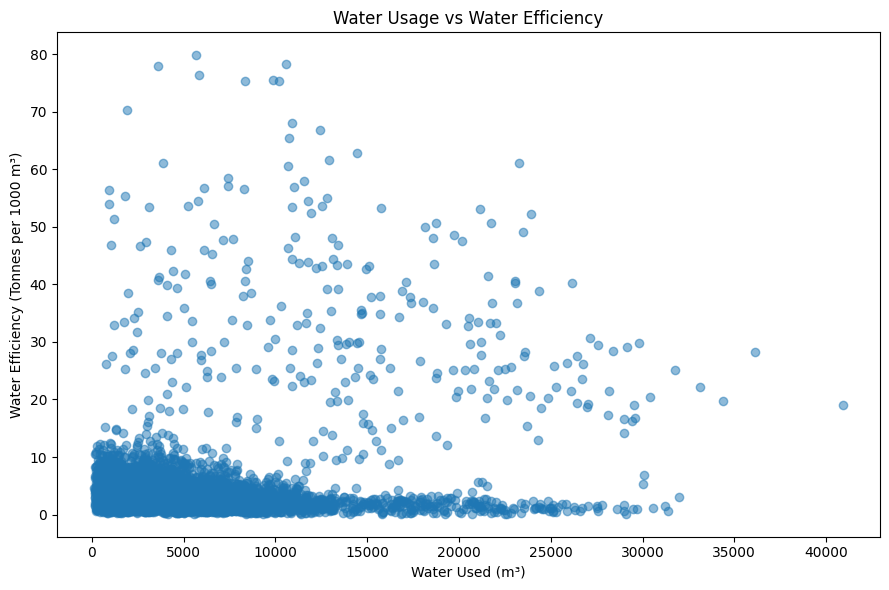

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Water_Used_m3"],
    df_clean["Water_Efficiency_t_per_1000m3"],
    alpha=0.5
)

plt.title("Water Usage vs Water Efficiency")
plt.xlabel("Water Used (m³)")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.tight_layout()
plt.show()

In [ ]:
economic_season = df_clean.groupby("Season")[[
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]].mean().round(2)

print(economic_season)

        Market_Price_INR_Tonne  Total_Cost_INR  Revenue_INR  Profit_INR
Season                                                                 
Kharif                44850.91       531804.41    710719.06   178914.65
Rabi                  44747.97       513836.58    601526.05    87689.47
Zaid                  44212.03       543976.73    519171.90   -24804.82


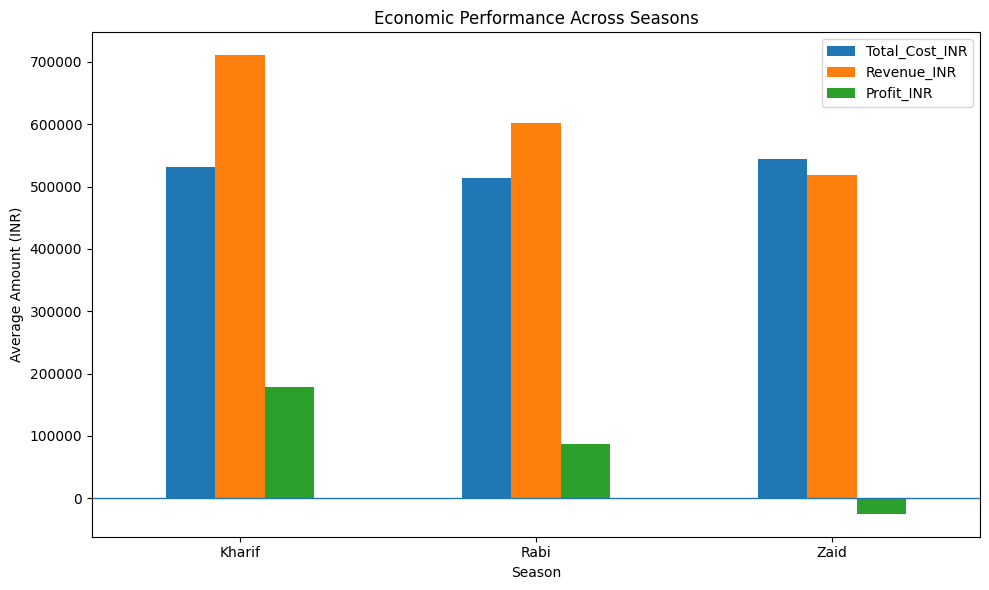

In [ ]:
economic_season[[
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Amount (INR)")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

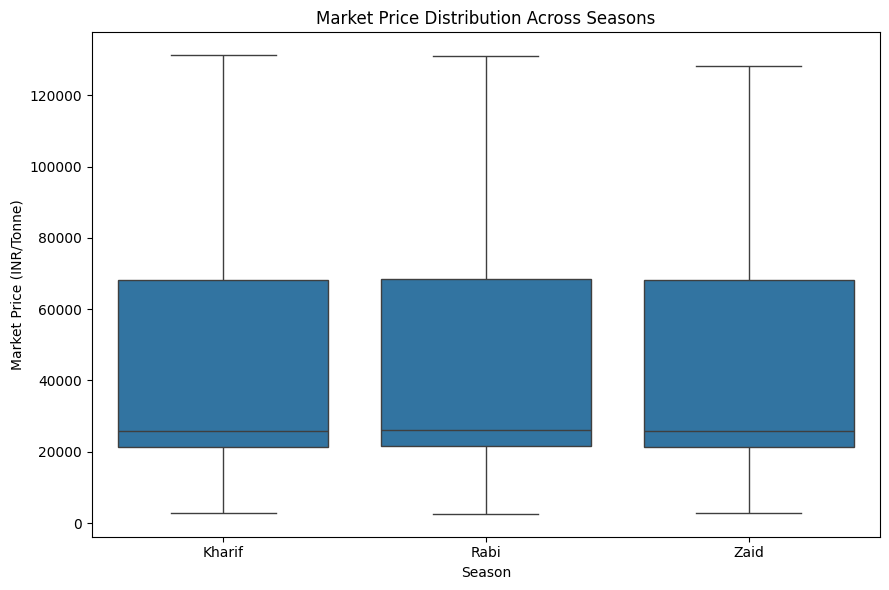

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Market_Price_INR_Tonne"
)

plt.title("Market Price Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Market Price (INR/Tonne)")
plt.tight_layout()
plt.show()

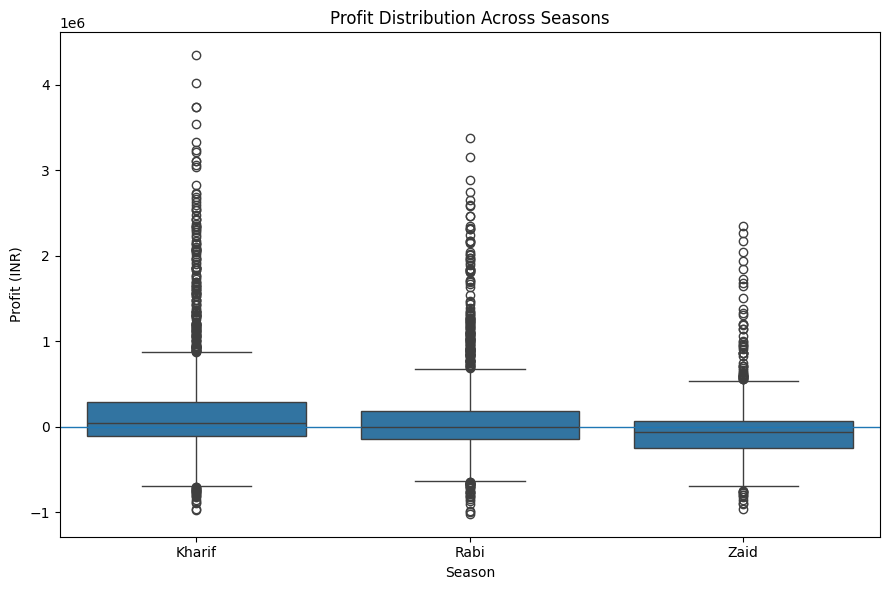

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

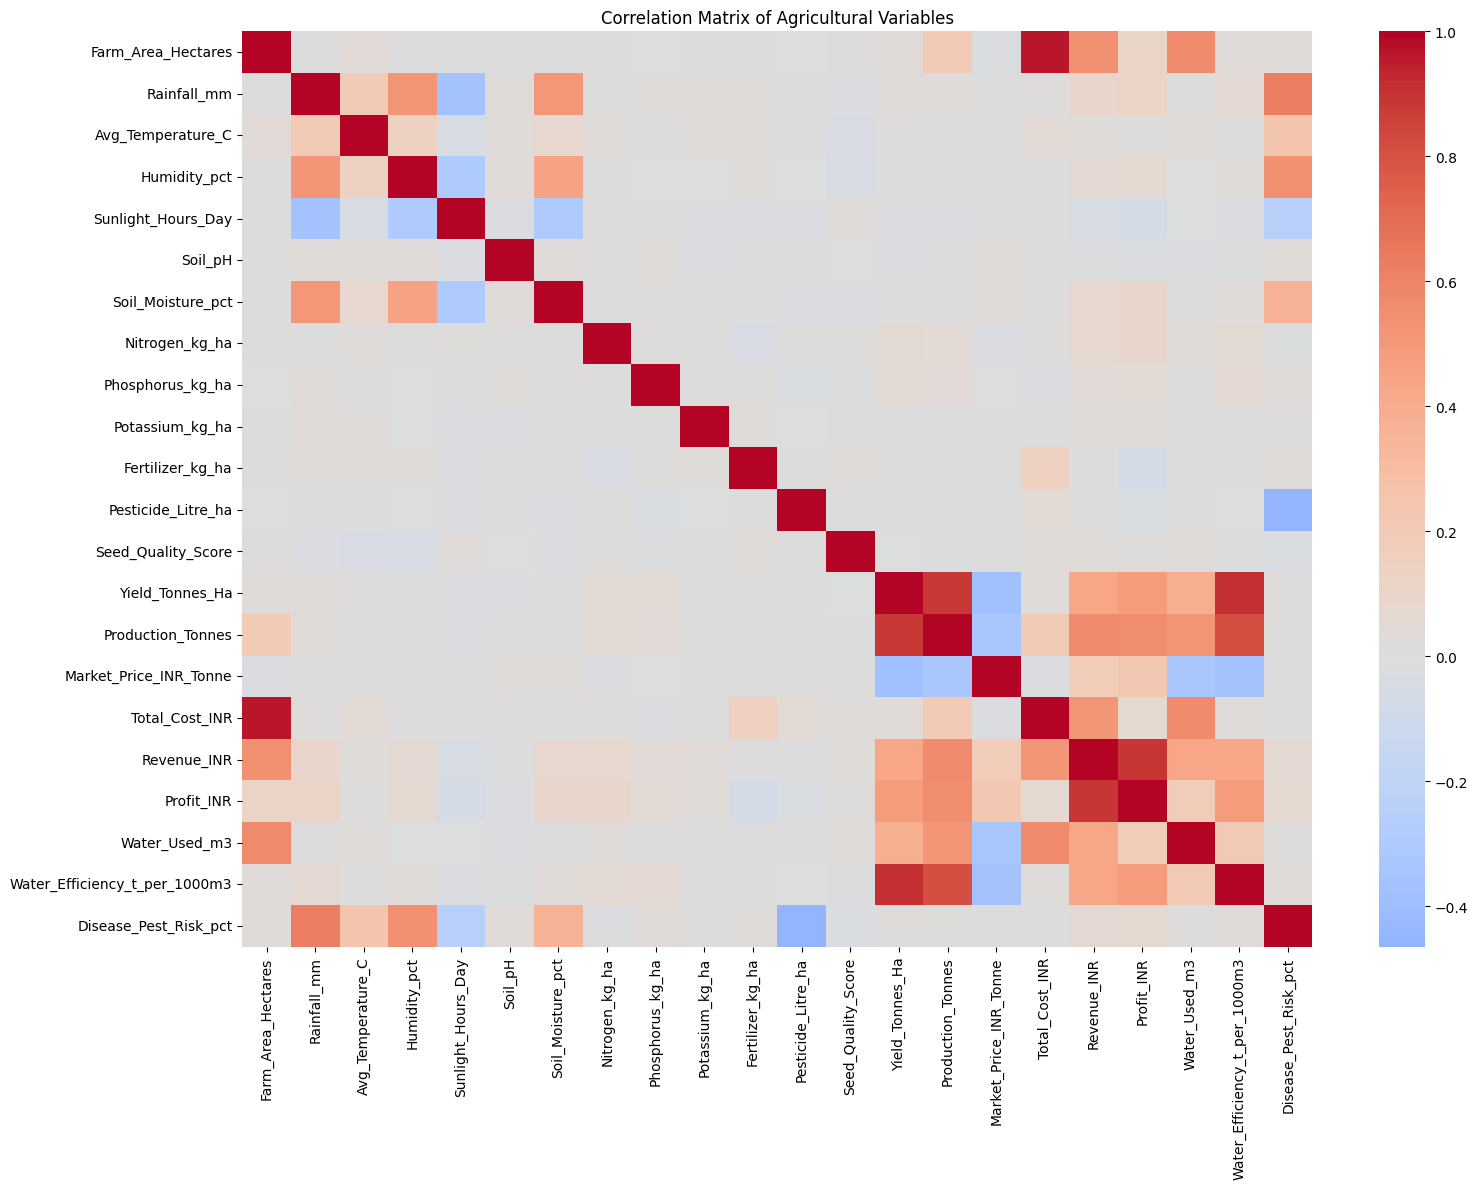

In [ ]:
numeric_cols = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()

In [ ]:
yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=abs, ascending=False)
)

print(yield_correlations)

Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Market_Price_INR_Tonne          -0.382607
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Soil_pH                         -0.020672
Sunlight_Hours_Day              -0.015341
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Pesticide_Litre_ha              -0.007779
Seed_Quality_Score              -0.007209
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Name: Yield_Tonnes_Ha, dtype: float64


In [ ]:
profit_correlations = (
    correlation_matrix["Profit_INR"]
    .drop("Profit_INR")
    .sort_values(key=abs, ascending=False)
)

print(profit_correlations)

Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.107648
Soil_Moisture_pct                0.091281
Nitrogen_kg_ha                   0.085016
Fertilizer_kg_ha                -0.073542
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Sunlight_Hours_Day              -0.054822
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Pesticide_Litre_ha              -0.025705
Soil_pH                         -0.013145
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Name: Profit_INR, dtype: float64


In [ ]:
from scipy.stats import f_oneway

kharif_yield = df_clean[
    df_clean["Season"] == "Kharif"
]["Yield_Tonnes_Ha"]

rabi_yield = df_clean[
    df_clean["Season"] == "Rabi"
]["Yield_Tonnes_Ha"]

zaid_yield = df_clean[
    df_clean["Season"] == "Zaid"
]["Yield_Tonnes_Ha"]

f_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Yield differs significantly across seasons.")
else:
    print("Result: No statistically significant difference in yield across seasons.")


F-statistic: 1.5438804542488311
p-value: 0.21367813841792296
Result: No statistically significant difference in yield across seasons.


In [ ]:
state_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
).round(2)

print(state_season_yield)

Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.68  3.47  4.45
Gujarat           6.34  5.44  4.07
Karnataka         6.46  4.57  6.62
Madhya Pradesh    5.99  3.76  5.48
Maharashtra       5.43  5.50  2.28
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.50  4.10
Telangana         5.55  4.78  4.25


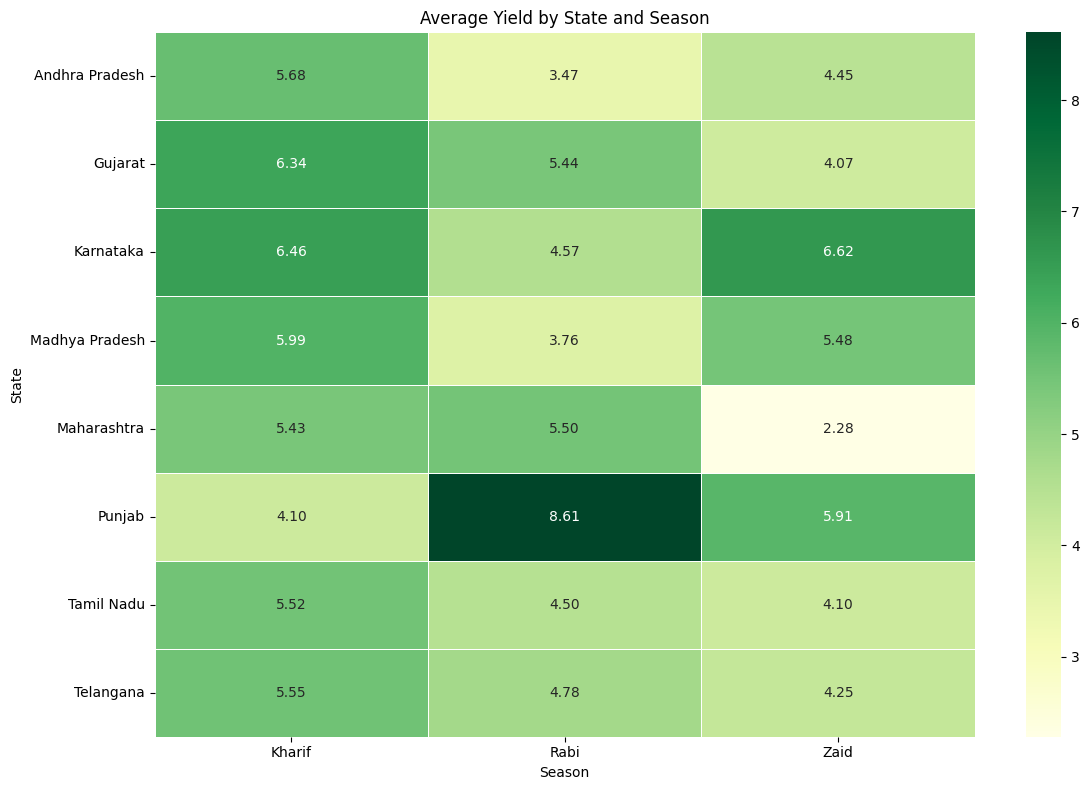

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [ ]:
high_yield = df_clean[
    df_clean["Yield_Tonnes_Ha"] >
    df_clean["Yield_Tonnes_Ha"].quantile(0.99)
].sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
)

print(high_yield[
    ["State", "District", "Crop", "Season",
     "Yield_Tonnes_Ha", "Production_Tonnes",
     "Profit_INR"]
].head(10))

               State  District       Crop  Season  Yield_Tonnes_Ha  \
1715         Gujarat    Indore  Sugarcane  Kharif           101.44   
3423  Andhra Pradesh    Indore  Sugarcane  Kharif            95.79   
3525  Andhra Pradesh     Erode  Sugarcane    Rabi            93.13   
1464         Gujarat    Nashik  Sugarcane  Kharif            91.98   
3523       Karnataka    Nashik  Sugarcane  Kharif            91.46   
2782         Gujarat  Nalgonda  Sugarcane    Rabi            91.32   
644   Andhra Pradesh  Ludhiana  Sugarcane  Kharif            89.34   
2847       Telangana  Warangal  Sugarcane  Kharif            87.76   
357           Punjab  Warangal  Sugarcane    Rabi            84.75   
1178       Karnataka  Nalgonda  Sugarcane  Kharif            83.79   

      Production_Tonnes  Profit_INR  
1715             641.10     1608291  
3423            1424.40     3330582  
3525             648.18     1471529  
1464             703.65     2216708  
3523              75.00      234320  
2

In [ ]:
extreme_crop_summary = high_yield.groupby("Crop").agg(
    Number_of_Extreme_Records=("Crop", "size"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).sort_values(
    "Number_of_Extreme_Records",
    ascending=False
)

print(extreme_crop_summary)

           Number_of_Extreme_Records  Average_Yield  Average_Profit
Crop                                                               
Sugarcane                         40       79.27425     1771368.025


In [ ]:
kharif_profit = df_clean[
    df_clean["Season"] == "Kharif"
]["Profit_INR"]

rabi_profit = df_clean[
    df_clean["Season"] == "Rabi"
]["Profit_INR"]

zaid_profit = df_clean[
    df_clean["Season"] == "Zaid"
]["Profit_INR"]

f_stat_profit, p_value_profit = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("F-statistic:", f_stat_profit)
print("p-value:", p_value_profit)

if p_value_profit < 0.05:
    print("Result: Profit differs significantly across seasons.")
else:
    print("Result: No statistically significant difference in profit across seasons.")

F-statistic: 34.29175033935195
p-value: 1.7124156677360182e-15
Result: Profit differs significantly across seasons.


In [ ]:
df_clean["Profit_Margin_pct"] = (
    df_clean["Profit_INR"] /
    df_clean["Revenue_INR"] * 100
)

profit_margin_season = df_clean.groupby("Season")[
    "Profit_Margin_pct"
].mean().round(2)

print(profit_margin_season)

Season
Kharif   -38.64
Rabi     -44.27
Zaid     -69.35
Name: Profit_Margin_pct, dtype: float64


In [ ]:
irrigation_profit = df_clean.groupby("Irrigation_Method")[
    ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3",
     "Water_Efficiency_t_per_1000m3"]
].mean().round(2)

print(irrigation_profit)

                   Yield_Tonnes_Ha  Profit_INR  Water_Used_m3  \
Irrigation_Method                                               
Drip                          6.58   219626.00        5918.75   
Flood                         4.86    73354.02        8026.47   
Rainfed                       4.60    79050.37        3549.55   
Sprinkler                     5.16    91121.08        6208.26   

                   Water_Efficiency_t_per_1000m3  
Irrigation_Method                                 
Drip                                        6.27  
Flood                                       3.44  
Rainfed                                     7.56  
Sprinkler                                   4.67  


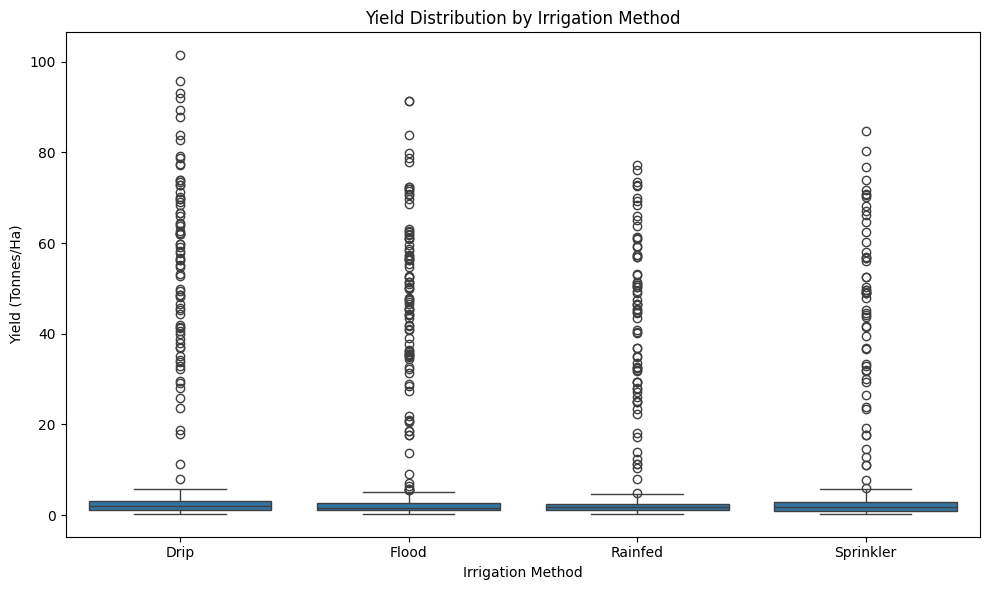

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

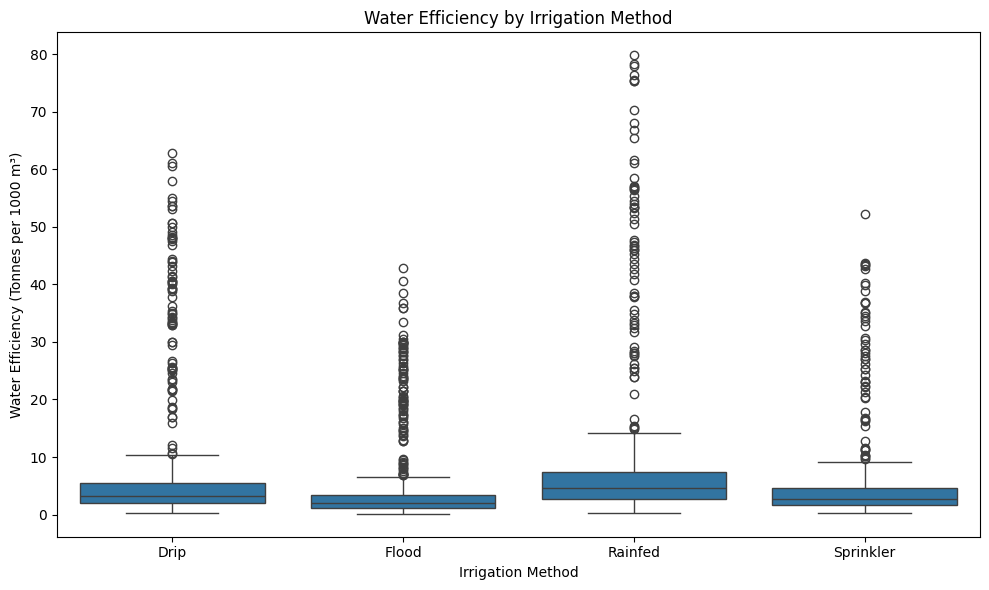

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3"
)

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.tight_layout()
plt.show()

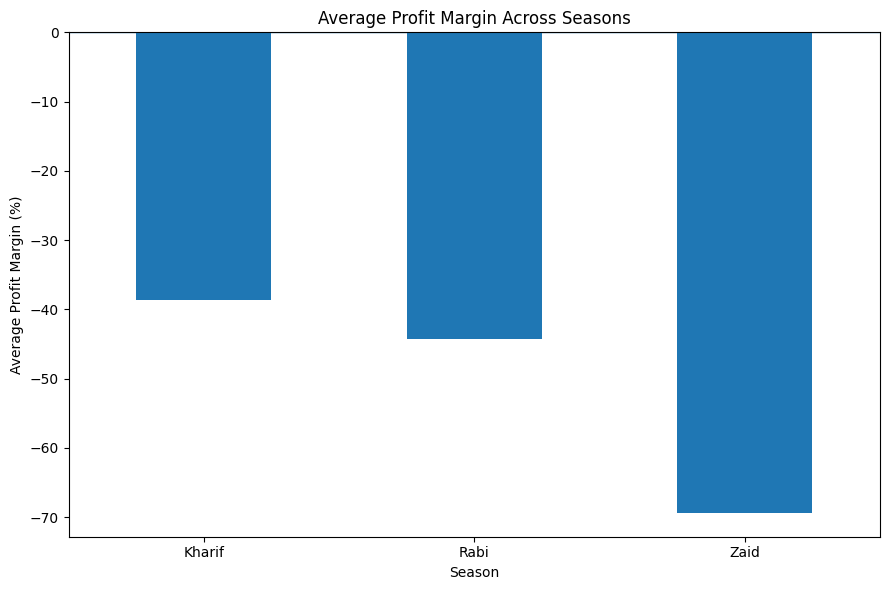

In [ ]:
plt.figure(figsize=(9, 6))

profit_margin_season.plot(
    kind="bar"
)

plt.title("Average Profit Margin Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit Margin (%)")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
crop_season_summary = df_clean.groupby(
    ["Crop", "Season"]
)[[
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3"
]].mean().round(2)

print(
    crop_season_summary.sort_values(
        "Yield_Tonnes_Ha",
        ascending=False
    ).head(15)
)

                  Yield_Tonnes_Ha  Profit_INR  Water_Efficiency_t_per_1000m3
Crop      Season                                                            
Sugarcane Kharif            53.46  1000790.81                          36.00
          Rabi              43.29   731612.86                          27.92
          Zaid              38.42   583635.80                          23.39
Maize     Kharif             2.97   -39332.67                           6.05
Rice      Kharif             2.70   -64903.40                           2.17
Maize     Rabi               2.60   -89133.40                           5.46
Rice      Rabi               2.32   -98427.87                           1.84
Maize     Zaid               2.29  -194049.17                           4.75
Wheat     Kharif             2.25  -105871.87                           4.76
          Rabi               2.06  -119954.57                           4.69
Rice      Zaid               1.90  -227239.34                           1.53

In [ ]:
top_crop = df_clean.groupby("Crop")["Yield_Tonnes_Ha"].mean().idxmax()

top_season = df_clean.groupby("Season")["Yield_Tonnes_Ha"].mean().idxmax()

top_profit_season = df_clean.groupby("Season")["Profit_INR"].mean().idxmax()

top_irrigation_yield = df_clean.groupby(
    "Irrigation_Method"
)["Yield_Tonnes_Ha"].mean().idxmax()

top_water_efficiency = df_clean.groupby(
    "Irrigation_Method"
)["Water_Efficiency_t_per_1000m3"].mean().idxmax()

print("Highest-yield crop:", top_crop)
print("Highest-yield season:", top_season)
print("Highest-profit season:", top_profit_season)
print("Highest-yield irrigation method:", top_irrigation_yield)
print("Most water-efficient irrigation method:", top_water_efficiency)
print("Seasonal yield ANOVA p-value:", p_value)
print("Seasonal profit ANOVA p-value:", p_value_profit)

Highest-yield crop: Sugarcane
Highest-yield season: Kharif
Highest-profit season: Kharif
Highest-yield irrigation method: Drip
Most water-efficient irrigation method: Rainfed
Seasonal yield ANOVA p-value: 0.21367813841792296
Seasonal profit ANOVA p-value: 1.7124156677360182e-15


## Key Findings

- Kharif recorded the highest average yield and profit among the three seasons.
- Zaid recorded the lowest average yield, lowest water efficiency, and negative average profit.
- Statistical testing showed that seasonal differences in yield were not statistically significant (ANOVA p-value = 0.2137).
- In contrast, profit differed significantly across seasons (ANOVA p-value < 0.001).
- Sugarcane was the highest-yielding crop and also recorded the highest average profit.
- Drip irrigation had the highest average yield and average profit among the irrigation methods.
- Rainfed farming recorded the highest water efficiency and the lowest average water usage.
- Seasonal yield patterns varied across states, showing that regional conditions can influence seasonal performance.
- Extreme high-yield observations were concentrated in Sugarcane, explaining part of the large variation in overall yield.

## Conclusions

The analysis shows that agricultural performance varies across seasons, crops, irrigation methods, and geographical regions.

Kharif showed the strongest overall performance in terms of average yield and profit, while Zaid showed weaker economic performance and lower water efficiency. However, the ANOVA test indicates that the observed differences in average yield between seasons are not statistically significant.

Economic performance showed a different pattern. Profit differed significantly across seasons, indicating that seasonal agricultural performance is more clearly reflected in economic outcomes than in average yield.

Crop-level analysis showed that Sugarcane had substantially higher yield and profit than the other crops in the dataset. Irrigation analysis also showed differences in yield, profit, and water efficiency across irrigation methods.

The regional analysis demonstrated that seasonal patterns are not identical across states. Therefore, agricultural planning should consider crop, region, season, water availability, and economic conditions together rather than relying on a single seasonal strategy.

## Data-Driven Recommendations

1. **Improve seasonal planning:**  
   Kharif showed stronger overall economic performance, while Zaid requires greater attention to profitability and resource efficiency.

2. **Promote efficient irrigation:**  
   Drip irrigation showed the highest average yield and profit, while rainfed farming showed the highest water efficiency. Irrigation decisions should therefore consider both productivity and water availability.

3. **Consider crop-specific strategies:**  
   Sugarcane showed exceptionally high yield and profit in this dataset. Crop selection should be evaluated together with resource requirements and regional suitability.

4. **Use region-specific planning:**  
   Seasonal performance varied considerably between states. Agricultural recommendations should therefore be adapted to local conditions rather than applying the same strategy everywhere.

5. **Monitor water usage:**  
   Flood irrigation recorded the highest average water usage and relatively low water efficiency. Improving irrigation efficiency may help reduce resource wastage.

6. **Investigate economic performance:**  
   Since profit showed statistically significant seasonal differences, seasonal cost, revenue, and market-price conditions should be monitored when planning agricultural activities.

7. **Investigate extreme observations:**  
   The very high yield observations were concentrated in Sugarcane. These records should be examined further to understand whether they represent genuine high productivity or unusual data characteristics.

## Limitations and Future Scope

### Limitations

- The analysis is based on the available dataset and its recorded variables.
- Correlation and group comparisons show relationships but do not establish causation.
- Extreme observations can influence averages, particularly for yield, production, revenue, and profit.
- The ANOVA analysis considers seasonal groups but does not account for all possible interactions between crop, region, irrigation, and environmental conditions.

### Future Scope

- Build predictive models for crop yield and profit.
- Develop region-specific seasonal recommendations.
- Apply advanced statistical tests and regression analysis.
- Study interactions between climate, irrigation, crop type, and soil conditions.
- Develop an interactive dashboard for farmers, agricultural planners, and policymakers.
- Incorporate historical weather and market-price data to improve seasonal forecasting.